# Adding Thinning to the thresholds

In [1]:
# imports
from importlib import reload
import os

import numpy as np
import h5py
import xarray
import pandas

from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
import matplotlib.gridspec as gridspec
import seaborn as sns

from skimage import morphology

from wrangler.plotting import cutout
from wrangler.ogcm import llc as wr_llc

from fronts.dbof import utils as dbof_utils
from fronts.dbof import io as dbof_io
from fronts.finding import dev as finding_dev
from fronts.finding import params as finding_params
from fronts.finding import pyboa as ff_pyboa
from fronts.finding import thin_cc
from fronts.finding import cc_sst_preproc

# DBOF_dev

In [2]:
dbof_dev_file = '../../fronts/runs/dbof/dev/llc4320_dbof_dev.json'

In [3]:
def plot(UID, field_data, fronts=None):
    reload(finding_dev)
    if fronts is None:
        fronts = np.zeros_like(field_data['Divb2'])
    finding_dev.front_fig6(None, fronts, field_data['Divb2'],
                                   field_data['SSTK'], field_data['b'], 
                                   field_data['DivSST2'],
                                   field_data['SSS'], field_data['DivSSS2'],
                               title=f'{UID}', show=True)

# Example

In [4]:
reload(dbof_utils)
UID_1 = 1322611708493510
field_data_1 = dbof_utils.grab_fields(dbof_dev_file, 'all', UID_1)

Read main table: /home/xavier/Projects/Oceanography/data/OGCM/DBOF/DBOF_dev/DBOF_dev.parquet
Grabbing fields for UID: 1322611708493510
Field SSSs not found for UID 1322611708493510


## Plot without fronts

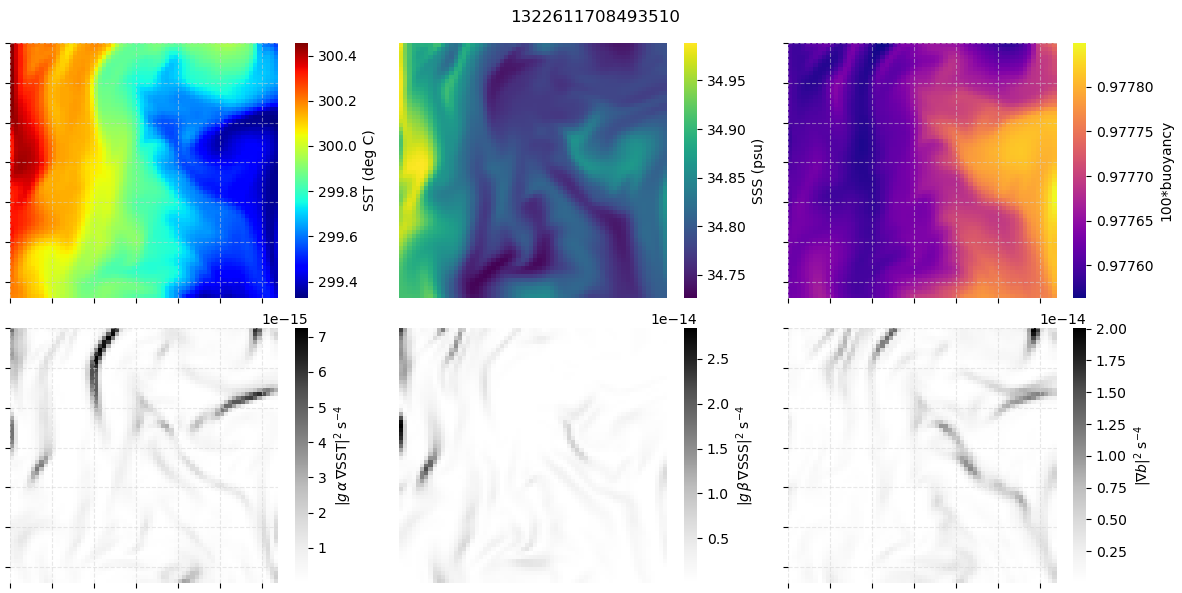

In [5]:
reload(finding_dev)
plot(UID_1, field_data_1)

# Threshold (40 pixel window, 90%)

In [6]:
fronts_40_90 = ff_pyboa.front_thresh(field_data_1['Divb2'], wndw=40, prcnt=90)
#fronts_40_90 = morphology.thin(fronts_40_90)

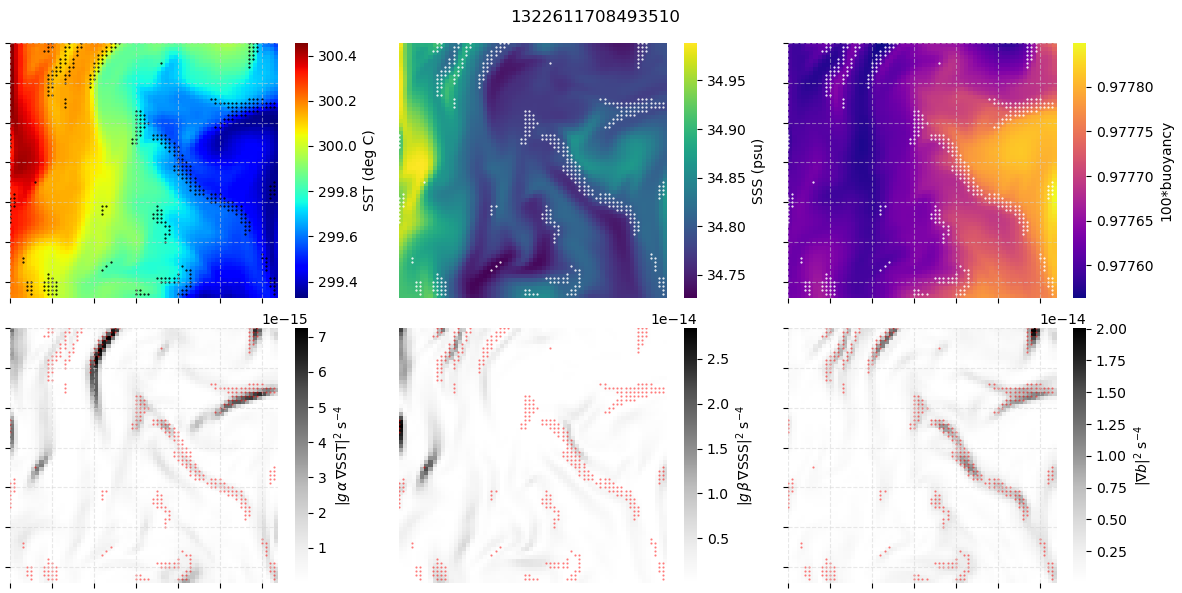

In [7]:
plot(UID_1, field_data_1, fronts=fronts_40_90)

## Thin with original

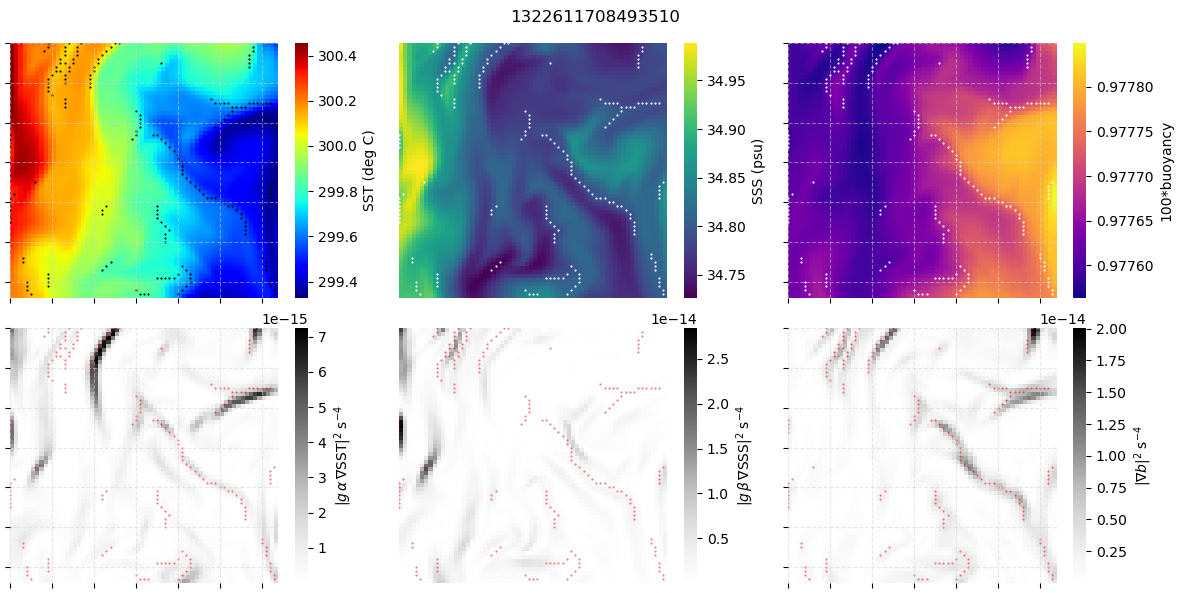

In [8]:
fronts_40_90_orig = morphology.thin(fronts_40_90)
plot(UID_1, field_data_1, fronts=fronts_40_90_orig)

## Thin with new

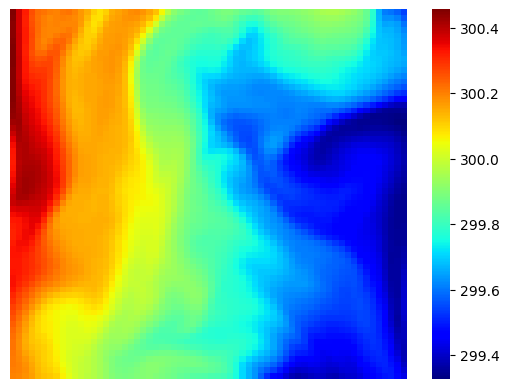

<Axes: >

In [9]:
cutout.show_image(field_data_1['SSTK'], show=True)

In [10]:
# Median subtract + convert to int16
reload(cc_sst_preproc)
med_SST,_ = cc_sst_preproc.preprocess_sst(field_data_1['SSTK'])

Step 1: Converting SST to integer counts...
  Input SST range: 299.33 - 300.46 K
  Valid pixels: 4,096
  Fill value pixels: 0

Step 2: Applying 3x3 median filter...
  Valid pixels after filtering: 4,096
  Output data range: 3118 - 3230 counts

Preprocessing complete!


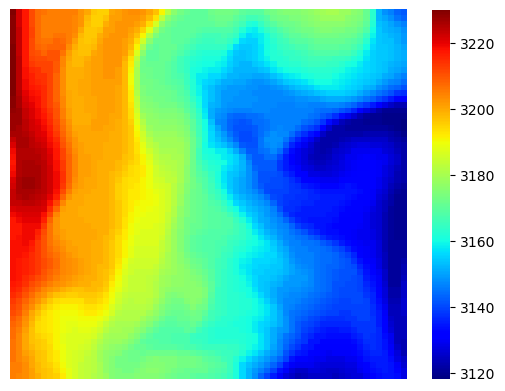

<Axes: >

In [11]:
cutout.show_image(med_SST, show=True)

In [12]:
med_SST

array([[3205, 3204, 3203, ..., 3134, 3133, 3128],
       [3205, 3205, 3203, ..., 3134, 3132, 3128],
       [3205, 3205, 3203, ..., 3134, 3130, 3126],
       ...,
       [3229, 3222, 3217, ..., 3150, 3148, 3146],
       [3229, 3222, 3217, ..., 3148, 3145, 3143],
       [3230, 3222, 3217, ..., 3146, 3143, 3142]], dtype=int16)

In [28]:
reload(thin_cc)
fronts_40_90_cc = thin_cc.thin(med_SST, fronts_40_90*4, debug=1)
#plot(UID_1, field_data_1, fronts=fronts_40_90_cc)

thin: Array dimensions: LenX=64, LenY=64
thin: Starting FIRST PASS (J-direction/vertical)
thin: Completed FIRST PASS
thin: Front pixels after first pass: 0
thin: Starting SECOND PASS (I-direction/horizontal)
thin: Completed SECOND PASS
thin: Final front pixels: 0


In [19]:
fronts_40_90_cc.max()

np.int16(0)

In [21]:
med_SST

array([[ 0.3624878 ,  0.35812378,  0.3449707 , ..., -0.33926392,
        -0.35855103, -0.4043579 ],
       [ 0.36636353,  0.36141968,  0.3465271 , ..., -0.33843994,
        -0.36895752, -0.42260742],
       [ 0.36968994,  0.36071777,  0.34298706, ..., -0.34542847,
        -0.38510132, -0.4395752 ],
       ...,
       [ 0.60873413,  0.5380554 ,  0.48034668, ..., -0.17977905,
        -0.1953125 , -0.236969  ],
       [ 0.6125183 ,  0.5378113 ,  0.47964478, ..., -0.20452881,
        -0.22232056, -0.26715088],
       [ 0.6195984 ,  0.53878784,  0.48397827, ..., -0.23764038,
        -0.2585144 , -0.29519653]], dtype=float32)

In [23]:
tmp = fronts_40_90*4
tmp.dtype

dtype('int64')